In [1]:
dpn_path = '/home/xucong24/Compiler/third_party/dqn/dqn_codecontest_test.csv'
tabular_q_path = '/home/xucong24/Compiler/third_party/CompilerGym-development/leaderboard/llvm_instcount/tabular_q/tabular_q_codecontest_test.csv'
random_search_path = '/home/xucong24/Compiler/third_party/CompilerGym-development/leaderboard/llvm_instcount/random_search/random_search_codecontest_test.csv'
greedy_search_path = '/home/xucong24/Compiler/third_party/CompilerGym-development/leaderboard/llvm_instcount/e_greedy/e_greedy_codecontest_test.csv'
ppo_path = '/home/xucong24/Compiler/third_party/PPO/ppo_codecontest_test.csv'
passformer_path = '/home/xucong24/Compiler/work_dirs/decode_eval_concat_v7_tmp_best/decode_all_results.csv'

In [23]:
import pandas as pd

# 读取前4个基线模型结果，并统一加 method 列
baseline_specs = [
    ("dqn", dpn_path),
    ("tabular_q", tabular_q_path),
    ("random_search", random_search_path),
    ("ppo", ppo_path),
    ("greedy_search", greedy_search_path),
]

baseline_dfs = []
for method_name, csv_path in baseline_specs:
    df = pd.read_csv(csv_path)
    df["method"] = method_name
    baseline_dfs.append(df)

baseline_df = pd.concat(baseline_dfs, ignore_index=True)

# # passformer 单独读取并筛选 reward > 0.5
# passformer_df = pd.read_csv(passformer_path)
# passformer_df = passformer_df[passformer_df["reward"] > 0.5].copy()
# passformer_df["method"] = "passformer"

print("baseline_df shape:", baseline_df.shape)
# print("passformer_df shape:", passformer_df.shape)

baseline_df shape: (500, 14)


In [5]:
from pathlib import Path
import numpy as np
import pandas as pd

pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 200)

WORK_DIRS = {
    "add_v2": Path("/home/xucong24/Compiler/work_dirs/decode_eval_cc_add_v2_best"),
    "concat_v7": Path("/home/xucong24/Compiler/work_dirs/decode_eval_cc_concat_v7_best"),
    "only_v1": Path("/home/xucong24/Compiler/work_dirs/decode_eval_cc_only_v1_best"),
}

REWARD_THRESHOLD = 0.5



In [41]:
# 读取三组 passformer 结果并拼接，添加 method 列
method_name_map = {
    "add_v2": "passformer_add",
    "concat_v7": "passformer_concat",
    "only_v1": "passformer_none",
}

passformer_dfs = []
for key, work_dir in WORK_DIRS.items():
    csv_path = work_dir / "decode_all_results.csv"
    df = pd.read_csv(csv_path)
    df["method"] = method_name_map[key]
    passformer_dfs.append(df)

passformer_df = pd.concat(passformer_dfs, ignore_index=True)

# sampling_best_temp: 在 sampling 温度候选中，为每个 method + benchmark 选 reward_max 最优的一条
# sampling_df = passformer_df[passformer_df["strategy"] == "sampling"].copy()
# idx = sampling_df.groupby(["method", "benchmark"])["reward_max"].idxmax()
# filtered_df = sampling_df.loc[idx].copy()
# filtered_df["strategy"] = "sampling_topp"

# # 如需额外阈值过滤，可取消注释
# filtered_df = filtered_df[filtered_df["reward_max"] > 0.5].copy()

# print("passformer_df shape:", passformer_df.shape)
# print("filtered_df shape:", filtered_df.shape)
# print(filtered_df[["method", "strategy"]].value_counts().rename("rows"))
# # filtered_df

In [51]:
import math
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

sns.set_theme(style="whitegrid", context="talk")

PASSFORMER_STRATEGY = "sampling_topp"  # 可改为 sampling_topp / greedy / beam / sampling
FIG_DIR = Path("/home/xucong24/Compiler/src/analysis/figures/baseline_compare")
FIG_DIR.mkdir(parents=True, exist_ok=True)


def normalize_benchmark_id(x: str) -> str:
    s = str(x)
    if s.startswith("benchmark://user-v0"):
        s = s.split("/")[-1]
        if s.endswith(".bc"):
            s = s[:-3]
    return s


# baseline: 每个方法 100 行
baseline_cols = {
    "benchmark": "benchmark_id",
    "ic_reduction": "ic_reduction",
    "optimized_ir_count": "optimized_ic",
    "o3_ir_count": "o3_ic",
    "oz_ir_count": "oz_ic",
    "walltime": "walltime",
    "reward": "reward",
}

baseline_df2 = baseline_df.copy()
baseline_df2["benchmark_id"] = baseline_df2["benchmark"].map(normalize_benchmark_id)
for c in ["ic_reduction", "optimized_ir_count", "o3_ir_count", "oz_ir_count", "walltime", "reward"]:
    if c in baseline_df2.columns:
        baseline_df2[c] = pd.to_numeric(baseline_df2[c], errors="coerce")

baseline_long = baseline_df2[["method", *baseline_cols.keys()]].rename(columns=baseline_cols)
baseline_long["strategy"] = "baseline"

# passformer: 取同一种 strategy 后，每个模型应为 100 行
passformer_eval = passformer_df[
    (passformer_df["strategy"] == PASSFORMER_STRATEGY)
    & (passformer_df["reward_max"] > 0.5)
].copy()
passformer_eval["benchmark_id"] = passformer_eval["benchmark"].map(normalize_benchmark_id)
for c in ["ic_reduction", "optimized_ic", "o3_ic", "oz_ic", "wall_time_total", "reward_max"]:
    if c in passformer_eval.columns:
        passformer_eval[c] = pd.to_numeric(passformer_eval[c], errors="coerce")

passformer_long = passformer_eval[
    ["method", "benchmark_id", "ic_reduction", "optimized_ic", "o3_ic", "oz_ic", "wall_time_total", "reward_max", "strategy"]
].rename(columns={"wall_time_total": "walltime", "reward_max": "reward"})

compare_df = pd.concat([baseline_long, passformer_long], ignore_index=True)
compare_df = compare_df.dropna(subset=["benchmark_id", "ic_reduction"]).copy()
compare_df["beat_oz"] = compare_df["optimized_ic"] < compare_df["oz_ic"]
compare_df["beat_o3"] = compare_df["optimized_ic"] < compare_df["o3_ic"]

method_order = [
    "tabular_q",
    "greedy_search",
    "random_search",
    "dqn",
    "ppo",
    "passformer_none",
    "passformer_add",
    "passformer_concat",
]
compare_df["method"] = pd.Categorical(compare_df["method"], categories=method_order, ordered=True)


# 仅对 PPO：去掉 ic_reduction 最高的前 10 条样本后再汇总
ppo_top10_idx = (
    compare_df.loc[compare_df["method"] == "ppo", "ic_reduction"]
    .sort_values(ascending=False)
    .head(10)
    .index
)
compare_df = compare_df.drop(index=ppo_top10_idx).copy()
compare_df_for_summary = compare_df

# O3/Oz 相关优化指标：策略相对 O3/Oz 的缩减比例（正值表示优于基线）
compare_df_for_summary["policy_vs_o3_reduction"] = np.where(
    compare_df_for_summary["o3_ic"] > 0,
    (compare_df_for_summary["o3_ic"] - compare_df_for_summary["optimized_ic"])
    / compare_df_for_summary["o3_ic"],
    np.nan,
)
compare_df_for_summary["policy_vs_oz_reduction"] = np.where(
    compare_df_for_summary["oz_ic"] > 0,
    (compare_df_for_summary["oz_ic"] - compare_df_for_summary["optimized_ic"])
    / compare_df_for_summary["oz_ic"],
    np.nan,
)


def geomean_positive(s: pd.Series) -> float:
    v = pd.to_numeric(s, errors="coerce")
    v = v[v > 0]
    if v.empty:
        return np.nan
    return float(np.exp(np.log(v).mean()))


summary_df = (
    compare_df_for_summary.groupby("method", observed=True)
    .agg(
        n=("benchmark_id", "nunique"),
        mean_ic_reduction=("ic_reduction", "mean"),
        median_ic_reduction=("ic_reduction", "median"),
        std_ic_reduction=("ic_reduction", "std"),
        mean_reward=("reward", "mean"),
        median_reward=("reward", "median"),
        std_reward=("reward", "std"),
        geomean_reward=("reward", geomean_positive),
        reward_positive_rate=("reward", lambda s: (s > 0).mean()),
        mean_walltime=("walltime", "mean"),
        beat_oz_rate=("beat_oz", "mean"),
        beat_o3_rate=("beat_o3", "mean"),
        mean_policy_vs_oz_reduction=("policy_vs_oz_reduction", "mean"),
        mean_policy_vs_o3_reduction=("policy_vs_o3_reduction", "mean"),
    )
)

# 额外添加 O3 / Oz 两行，直接由 tabular_q 的 O0/O3/Oz 指令数计算
tab_q = baseline_df2[baseline_df2["method"] == "tabular_q"].copy()
tab_q = tab_q.dropna(subset=["original_ir_count", "o3_ir_count", "oz_ir_count"])
tab_q = tab_q[tab_q["original_ir_count"] > 0]

if not tab_q.empty:
    o3_red = (tab_q["original_ir_count"] - tab_q["o3_ir_count"]) / tab_q["original_ir_count"]
    oz_red = (tab_q["original_ir_count"] - tab_q["oz_ir_count"]) / tab_q["original_ir_count"]

    extra_rows = pd.DataFrame(
        [
            {
                "method": "O3",
                "n": tab_q["benchmark_id"].nunique(),
                "mean_ic_reduction": o3_red.mean(),
                "median_ic_reduction": o3_red.median(),
                "std_ic_reduction": o3_red.std(),
                "mean_reward": np.nan,
                "median_reward": np.nan,
                "std_reward": np.nan,
                "geomean_reward": np.nan,
                "reward_positive_rate": np.nan,
                "mean_walltime": np.nan,
                "beat_oz_rate": (tab_q["o3_ir_count"] < tab_q["oz_ir_count"]).mean(),
                "beat_o3_rate": 0.0,
                "mean_policy_vs_oz_reduction": ((tab_q["oz_ir_count"] - tab_q["o3_ir_count"]) / tab_q["oz_ir_count"]).mean(),
                "mean_policy_vs_o3_reduction": 0.0,
            },
            {
                "method": "Oz",
                "n": tab_q["benchmark_id"].nunique(),
                "mean_ic_reduction": oz_red.mean(),
                "median_ic_reduction": oz_red.median(),
                "std_ic_reduction": oz_red.std(),
                "mean_reward": np.nan,
                "median_reward": np.nan,
                "std_reward": np.nan,
                "geomean_reward": np.nan,
                "reward_positive_rate": np.nan,
                "mean_walltime": np.nan,
                "beat_oz_rate": 0.0,
                "beat_o3_rate": (tab_q["oz_ir_count"] < tab_q["o3_ir_count"]).mean(),
                "mean_policy_vs_oz_reduction": 0.0,
                "mean_policy_vs_o3_reduction": ((tab_q["o3_ir_count"] - tab_q["oz_ir_count"]) / tab_q["o3_ir_count"]).mean(),
            },
        ]
    ).set_index("method")

    summary_df = pd.concat([summary_df, extra_rows], axis=0)

summary_df = summary_df.sort_values("mean_ic_reduction", ascending=False)

print(f"PASSFORMER_STRATEGY = {PASSFORMER_STRATEGY}")
print(f"Filtered PPO top-10 ic_reduction rows: {len(ppo_top10_idx)}")
summary_df.round(4)

PASSFORMER_STRATEGY = sampling_topp
Filtered PPO top-10 ic_reduction rows: 10


,n,mean_ic_reduction,median_ic_reduction,std_ic_reduction,mean_reward,median_reward,std_reward,geomean_reward,reward_positive_rate,mean_walltime,beat_oz_rate,beat_o3_rate,mean_policy_vs_oz_reduction,mean_policy_vs_o3_reduction
method,,,,,,,,,,,,,,
passformer_concat,99,0.5112,0.5394,0.0969,1.0397,1.0264,0.1096,1.0345,1.0000,20.3500,0.6667,0.9091,0.0371,0.1239
ppo,90,0.5071,0.5465,0.1164,1.0491,1.0479,0.1790,1.0514,0.9889,10.4713,0.7667,0.9111,0.0572,0.1489
passformer_add,98,0.5048,0.5310,0.0953,1.0208,1.0164,0.1022,1.0162,1.0000,23.5919,0.5714,0.8673,0.0204,0.1105
passformer_none,99,0.5041,0.5238,0.0972,1.0247,1.0145,0.1086,1.0195,1.0000,23.6811,0.6263,0.8586,0.0233,0.1117
Oz,100,0.4878,0.5224,0.1023,NaN,NaN,NaN,NaN,NaN,NaN,0.0000,0.9200,0.0000,0.0881
dqn,100,0.4823,0.5251,0.1072,0.9773,0.9858,0.1388,0.9817,0.9900,10.2758,0.2600,0.7100,-0.0116,0.0772
random_search,100,0.4792,0.5119,0.1068,0.9725,0.9787,0.1416,0.9767,0.9900,10.3165,0.3300,0.6700,-0.0177,0.0744
greedy_search,100,0.4187,0.4404,0.1052,0.8445,0.8793,0.1329,0.8461,0.9900,14.0342,0.0300,0.2100,-0.1409,-0.0397
O3,100,0.4011,0.4958,0.2584,NaN,NaN,NaN,NaN,NaN,NaN,0.0200,0.0000,-0.1667,0.0000


/tmp/ipykernel_110832/4159432986.py:20: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([name_map.get(m, m) for m in method_order], rotation=25, ha="right")


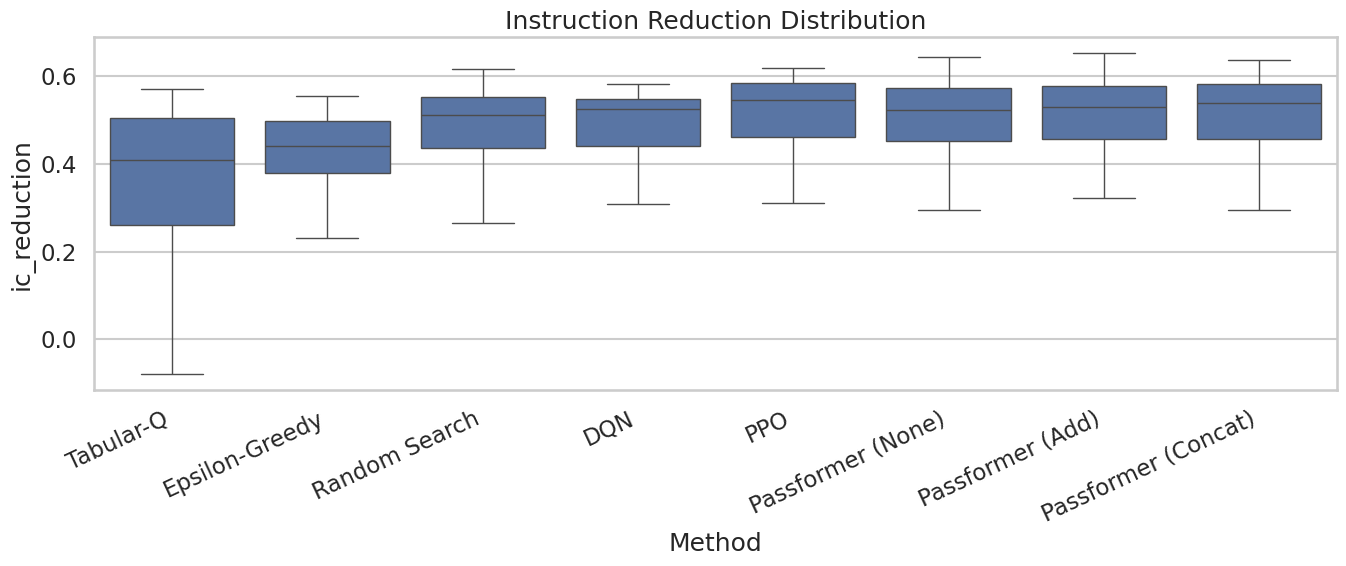

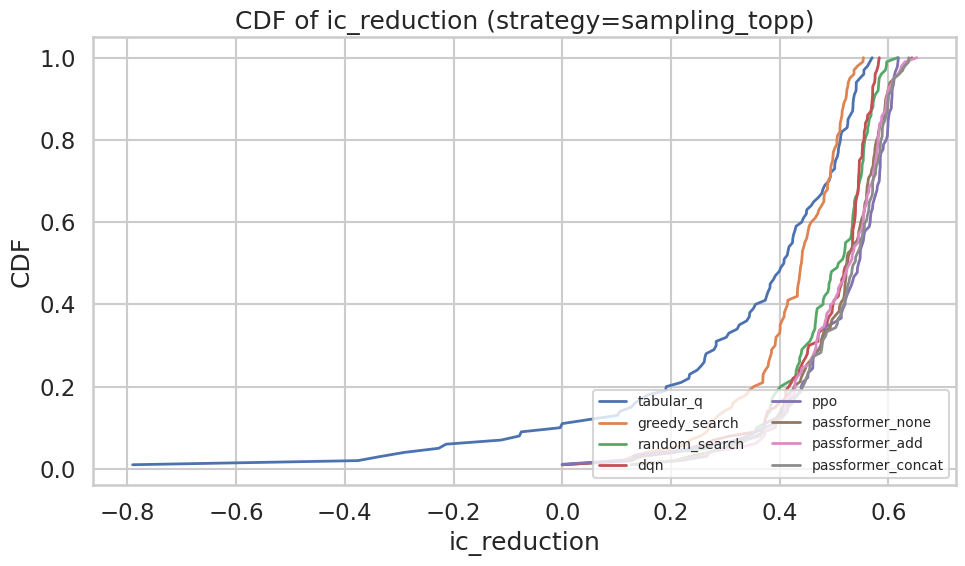

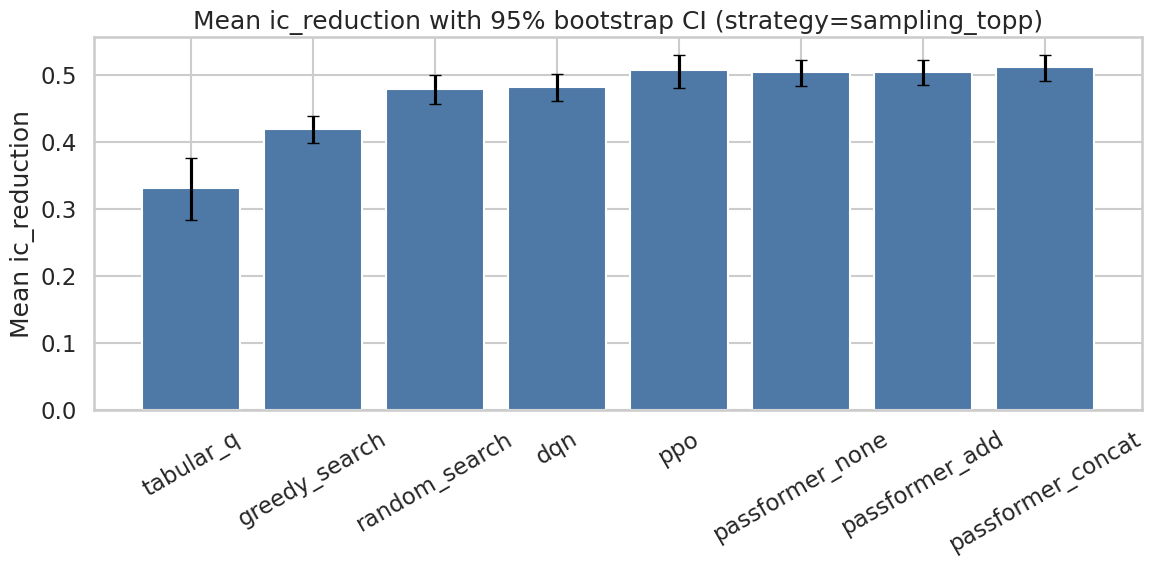

Saved figures to: /home/xucong24/Compiler/src/analysis/figures/baseline_compare


In [53]:
# 图1: 各方法 ic_reduction 分布（箱线图）
plt.figure(figsize=(14, 6))
ax = sns.boxplot(
    data=compare_df,
    x="method",
    y="ic_reduction",
    order=method_order,
    showfliers=False,
)
name_map = {
    "tabular_q": "Tabular-Q",
    "greedy_search": "Epsilon-Greedy",
    "random_search": "Random Search",
    "dqn": "DQN",
    "ppo": "PPO",
    "passformer_none": "Passformer (None)",
    "passformer_add": "Passformer (Add)",
    "passformer_concat": "Passformer (Concat)",
}
ax.set_xticklabels([name_map.get(m, m) for m in method_order], rotation=25, ha="right")
ax.set_title(f"Instruction Reduction Distribution")
ax.set_xlabel("Method")
ax.set_ylabel("ic_reduction")
plt.tight_layout()
plt.savefig(FIG_DIR / f"box_ic_reduction_{PASSFORMER_STRATEGY}.png", dpi=220)
plt.show()

# 图2: CDF（更适合论文比较尾部差异）
plt.figure(figsize=(10, 6))
for m in method_order:
    sub = compare_df[compare_df["method"] == m]["ic_reduction"].dropna().sort_values().to_numpy()
    if len(sub) == 0:
        continue
    y = np.arange(1, len(sub) + 1) / len(sub)
    plt.plot(sub, y, label=m, linewidth=2)

plt.xlabel("ic_reduction")
plt.ylabel("CDF")
plt.title(f"CDF of ic_reduction (strategy={PASSFORMER_STRATEGY})")
plt.legend(loc="lower right", ncol=2, fontsize=10)
plt.tight_layout()
plt.savefig(FIG_DIR / f"cdf_ic_reduction_{PASSFORMER_STRATEGY}.png", dpi=220)
plt.show()

# 图3: 均值+95% bootstrap CI
rng = np.random.default_rng(42)
boot_rows = []
for m in method_order:
    values = compare_df.loc[compare_df["method"] == m, "ic_reduction"].dropna().to_numpy()
    if len(values) == 0:
        continue
    boots = []
    for _ in range(2000):
        sample = rng.choice(values, size=len(values), replace=True)
        boots.append(sample.mean())
    low, high = np.percentile(boots, [2.5, 97.5])
    boot_rows.append({
        "method": m,
        "mean": values.mean(),
        "ci_low": low,
        "ci_high": high,
    })

boot_df = pd.DataFrame(boot_rows)

plt.figure(figsize=(12, 6))
x = np.arange(len(boot_df))
plt.bar(x, boot_df["mean"], color="#4e79a7")
plt.errorbar(
    x,
    boot_df["mean"],
    yerr=[boot_df["mean"] - boot_df["ci_low"], boot_df["ci_high"] - boot_df["mean"]],
    fmt="none",
    ecolor="black",
    capsize=4,
)
plt.xticks(x, boot_df["method"], rotation=30)
plt.ylabel("Mean ic_reduction")
plt.title(f"Mean ic_reduction with 95% bootstrap CI (strategy={PASSFORMER_STRATEGY})")
plt.tight_layout()
plt.savefig(FIG_DIR / f"bar_mean_ci_{PASSFORMER_STRATEGY}.png", dpi=220)
plt.show()

print("Saved figures to:", FIG_DIR)

In [ ]:
# 配对比较：以 ppo 作为参考，做每个 benchmark 的差值统计
# 不依赖 scipy，使用 sign test 的双侧 p-value

def sign_test_pvalue(diff_values: np.ndarray) -> float:
    d = diff_values[np.abs(diff_values) > 1e-12]
    n = len(d)
    if n == 0:
        return 1.0
    k = int((d > 0).sum())
    k_small = min(k, n - k)
    tail = sum(math.comb(n, i) for i in range(0, k_small + 1)) / (2 ** n)
    return min(1.0, 2 * tail)

pivot_ic = compare_df.pivot_table(index="benchmark_id", columns="method", values="ic_reduction", aggfunc="mean")

ref_method = "ppo"
pairwise_rows = []
for m in method_order:
    if m == ref_method or m not in pivot_ic.columns:
        continue
    pair = pivot_ic[[ref_method, m]].dropna()
    if pair.empty:
        continue
    diff = pair[m] - pair[ref_method]
    pairwise_rows.append(
        {
            "method": m,
            "n_pairs": len(pair),
            "mean_diff_vs_ppo": diff.mean(),
            "median_diff_vs_ppo": diff.median(),
            "win_rate_vs_ppo": (diff > 0).mean(),
            "sign_test_pvalue": sign_test_pvalue(diff.to_numpy()),
        }
    )

pairwise_df = pd.DataFrame(pairwise_rows).sort_values("mean_diff_vs_ppo", ascending=False)
pairwise_df.round(4)